#### Project 10 - Wholesale Customers Clustering
Govardhan

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


---
### 1 - Data Loading and Inspection

In [8]:
wholesale_customers_data = pd.read_csv("./Wholesale_customers_data.csv")
print(f"Shape of the Data: {wholesale_customers_data.shape}")
wholesale_customers_data.head(10)

Shape of the Data: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [9]:
wholesale_customers_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [10]:
wholesale_customers_data.describe().round(1)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
mean,1.3,2.5,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,0.5,0.8,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
25%,1.0,2.0,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,1.0,3.0,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,2.0,3.0,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


In [11]:
# NUll Values
print("Missing Values per column")
wholesale_customers_data.isnull().sum()

Missing Values per column


Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

---

## 2 -- Exploratory Data Analysis
### 2.1 Distribution of Spending Features

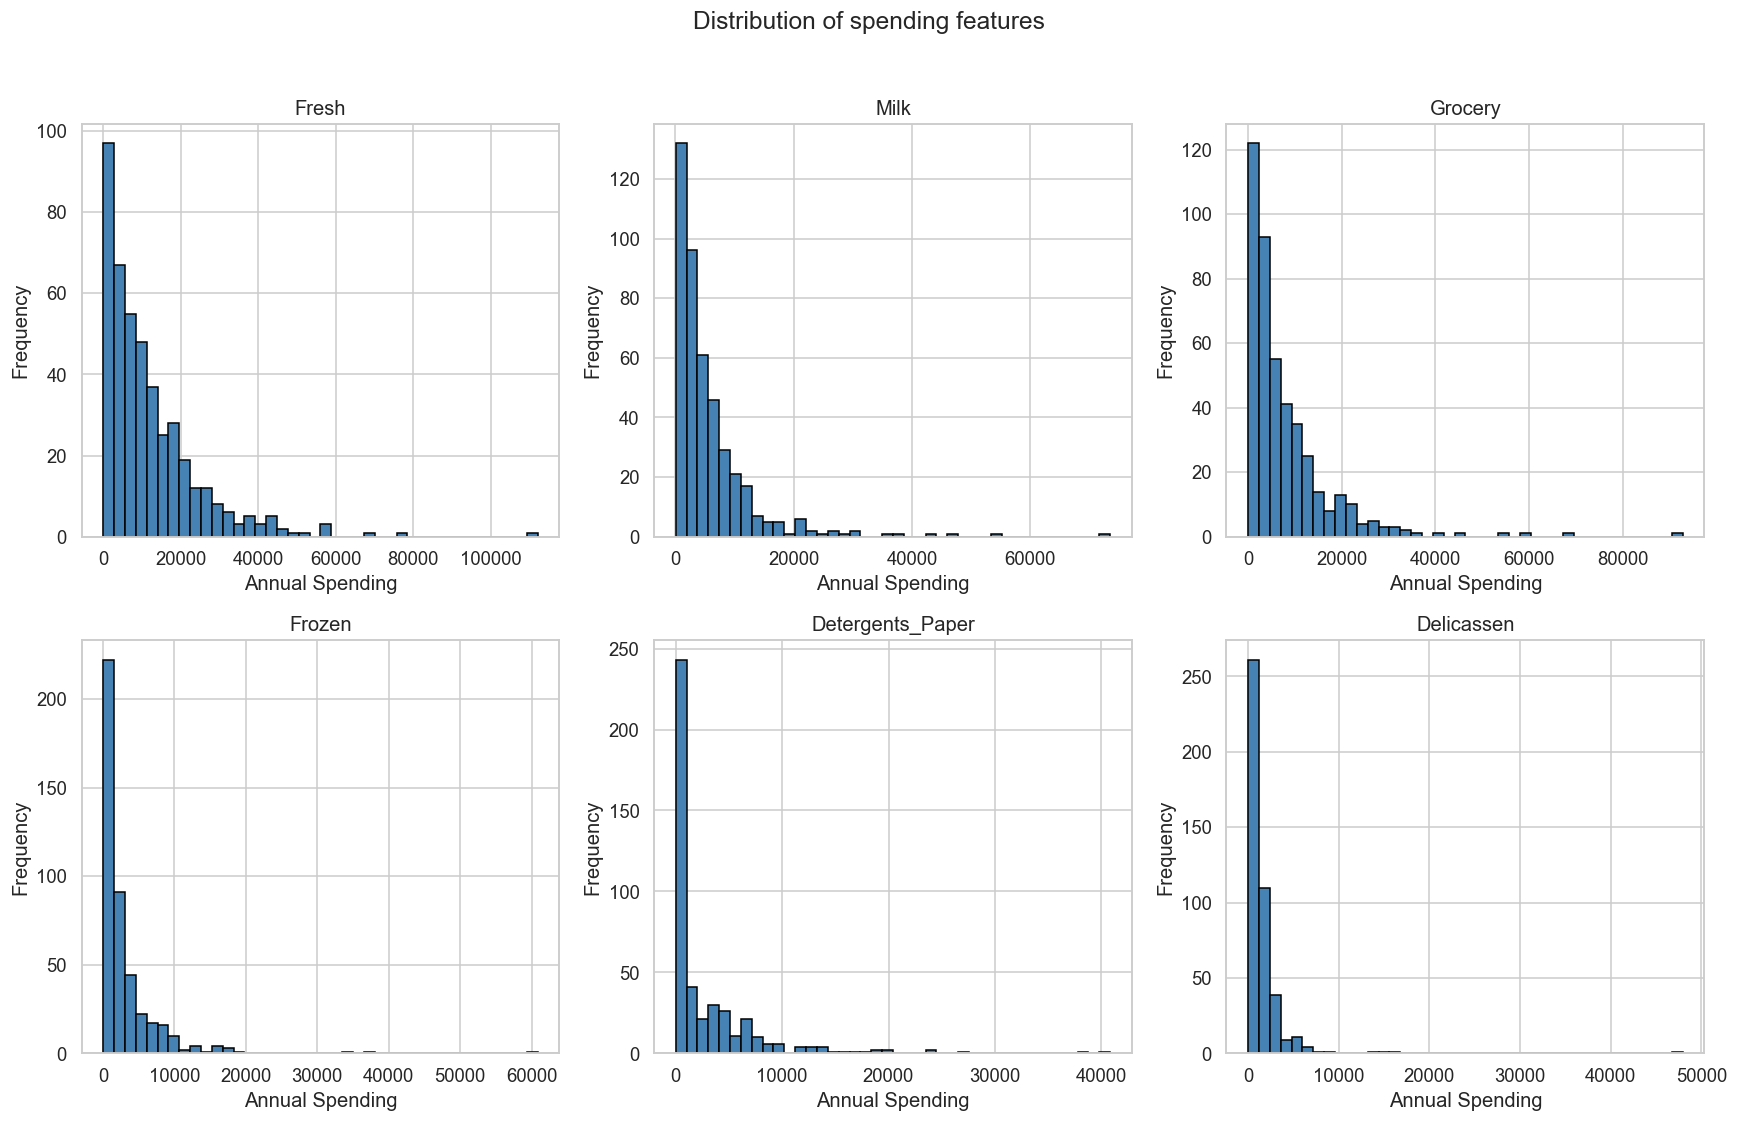

In [12]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen']
fig, axes = plt.subplots(2, 3, figsize = (16, 10))
for i, col in enumerate(spending_cols):
    ax = axes[i//3, i % 3]
    ax.hist(wholesale_customers_data[col], bins = 40, edgecolor = "black", color="steelblue")
    ax.set_title(col)
    ax.set_xlabel('Annual Spending')
    ax.set_ylabel('Frequency')
plt.suptitle("Distribution of spending features", fontsize = 16, y = 1.02)
plt.tight_layout()
plt.show()

In [13]:
print("Skewness of Spending Features")
wholesale_customers_data[spending_cols].skew().round(2)

Skewness of Spending Features


Fresh                2.56
Milk                 4.05
Grocery              3.59
Frozen               5.91
Detergents_Paper     3.63
Delicassen          11.15
dtype: float64

Observations: All the feature skewness is more than 2.00 and between the 2.56 to 11.15. There is a larger tail onto to the right it is highly right skewed. Mean > Median. Log Transformation will be needed before clustering

### 2.2 Outlier - Detection (Box Plot)

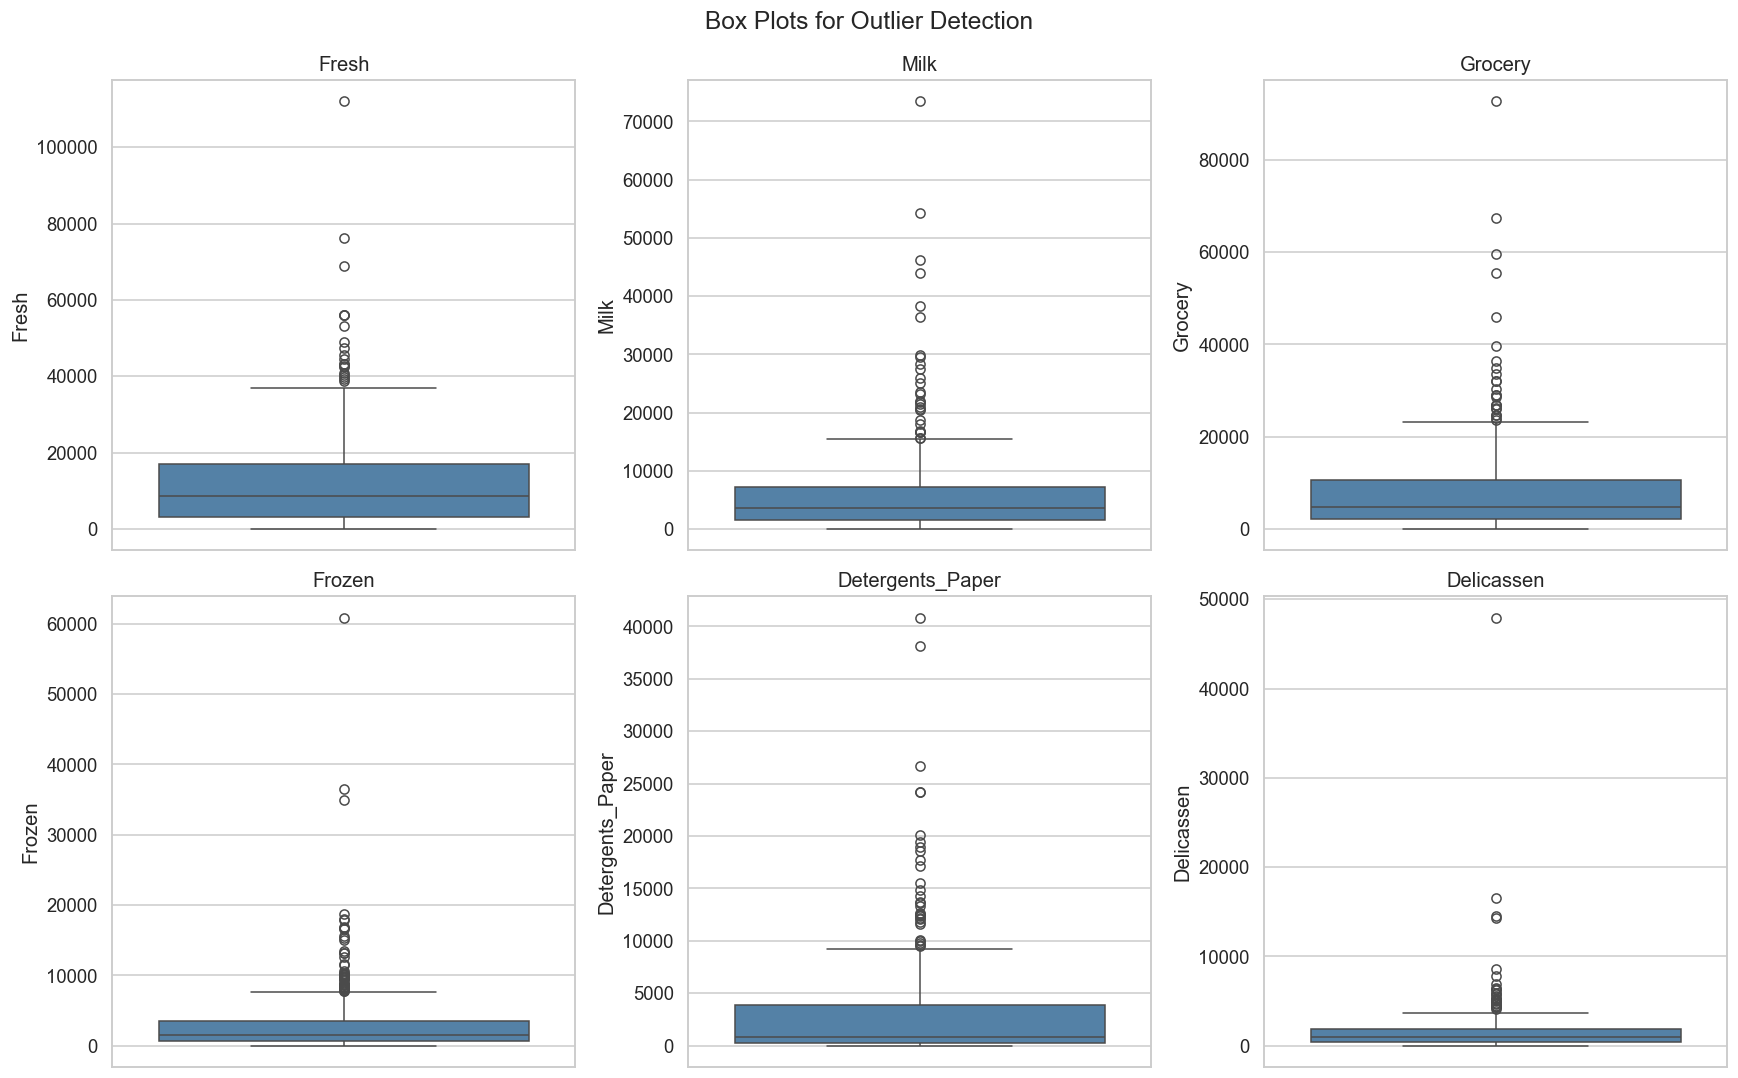

In [14]:
fig, axes = plt.subplots(2, 3, figsize = (16, 10))
for i, col in enumerate(spending_cols):
    ax = axes[i//3, i % 3]
    sns.boxplot(y = wholesale_customers_data[col], ax = ax, color='steelblue')
    ax.set_title(col)
plt.suptitle("Box Plots for Outlier Detection", fontsize = 16)
plt.tight_layout()
plt.show()

### 2.3 Correlation HeatMap

Text(0.5, 1.0, 'Correlation HeatMap of Spending Features')

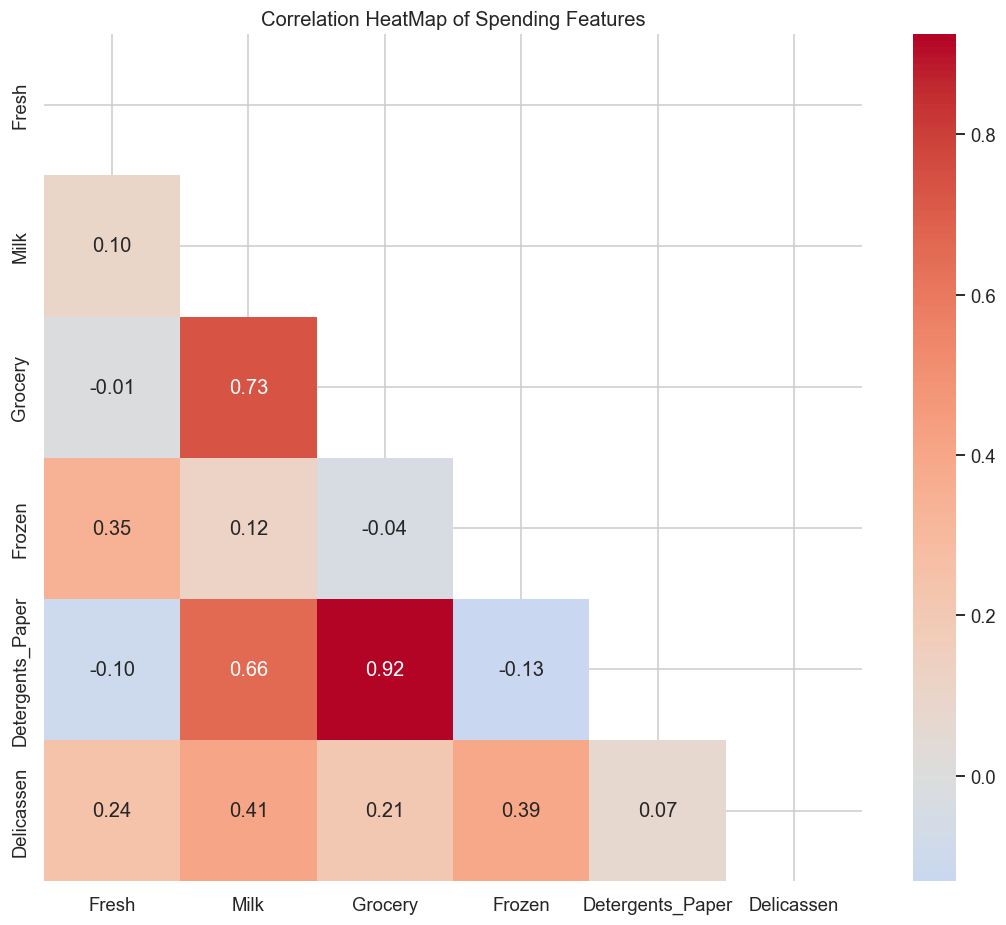

In [15]:
plt.figure(figsize=(12, 10))
corr = wholesale_customers_data[spending_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask = mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=False, linewidths=0)
plt.title("Correlation HeatMap of Spending Features")

Observations: Grocery and Detergents_Papers columns Highly Correlates to each other (0.92) Milk Correlates with both. This suggests a households/retails staple purchasing pattern. Fresh and frozen are more independent. 

### 2.4 Pair-Plot(Colored by Channel)

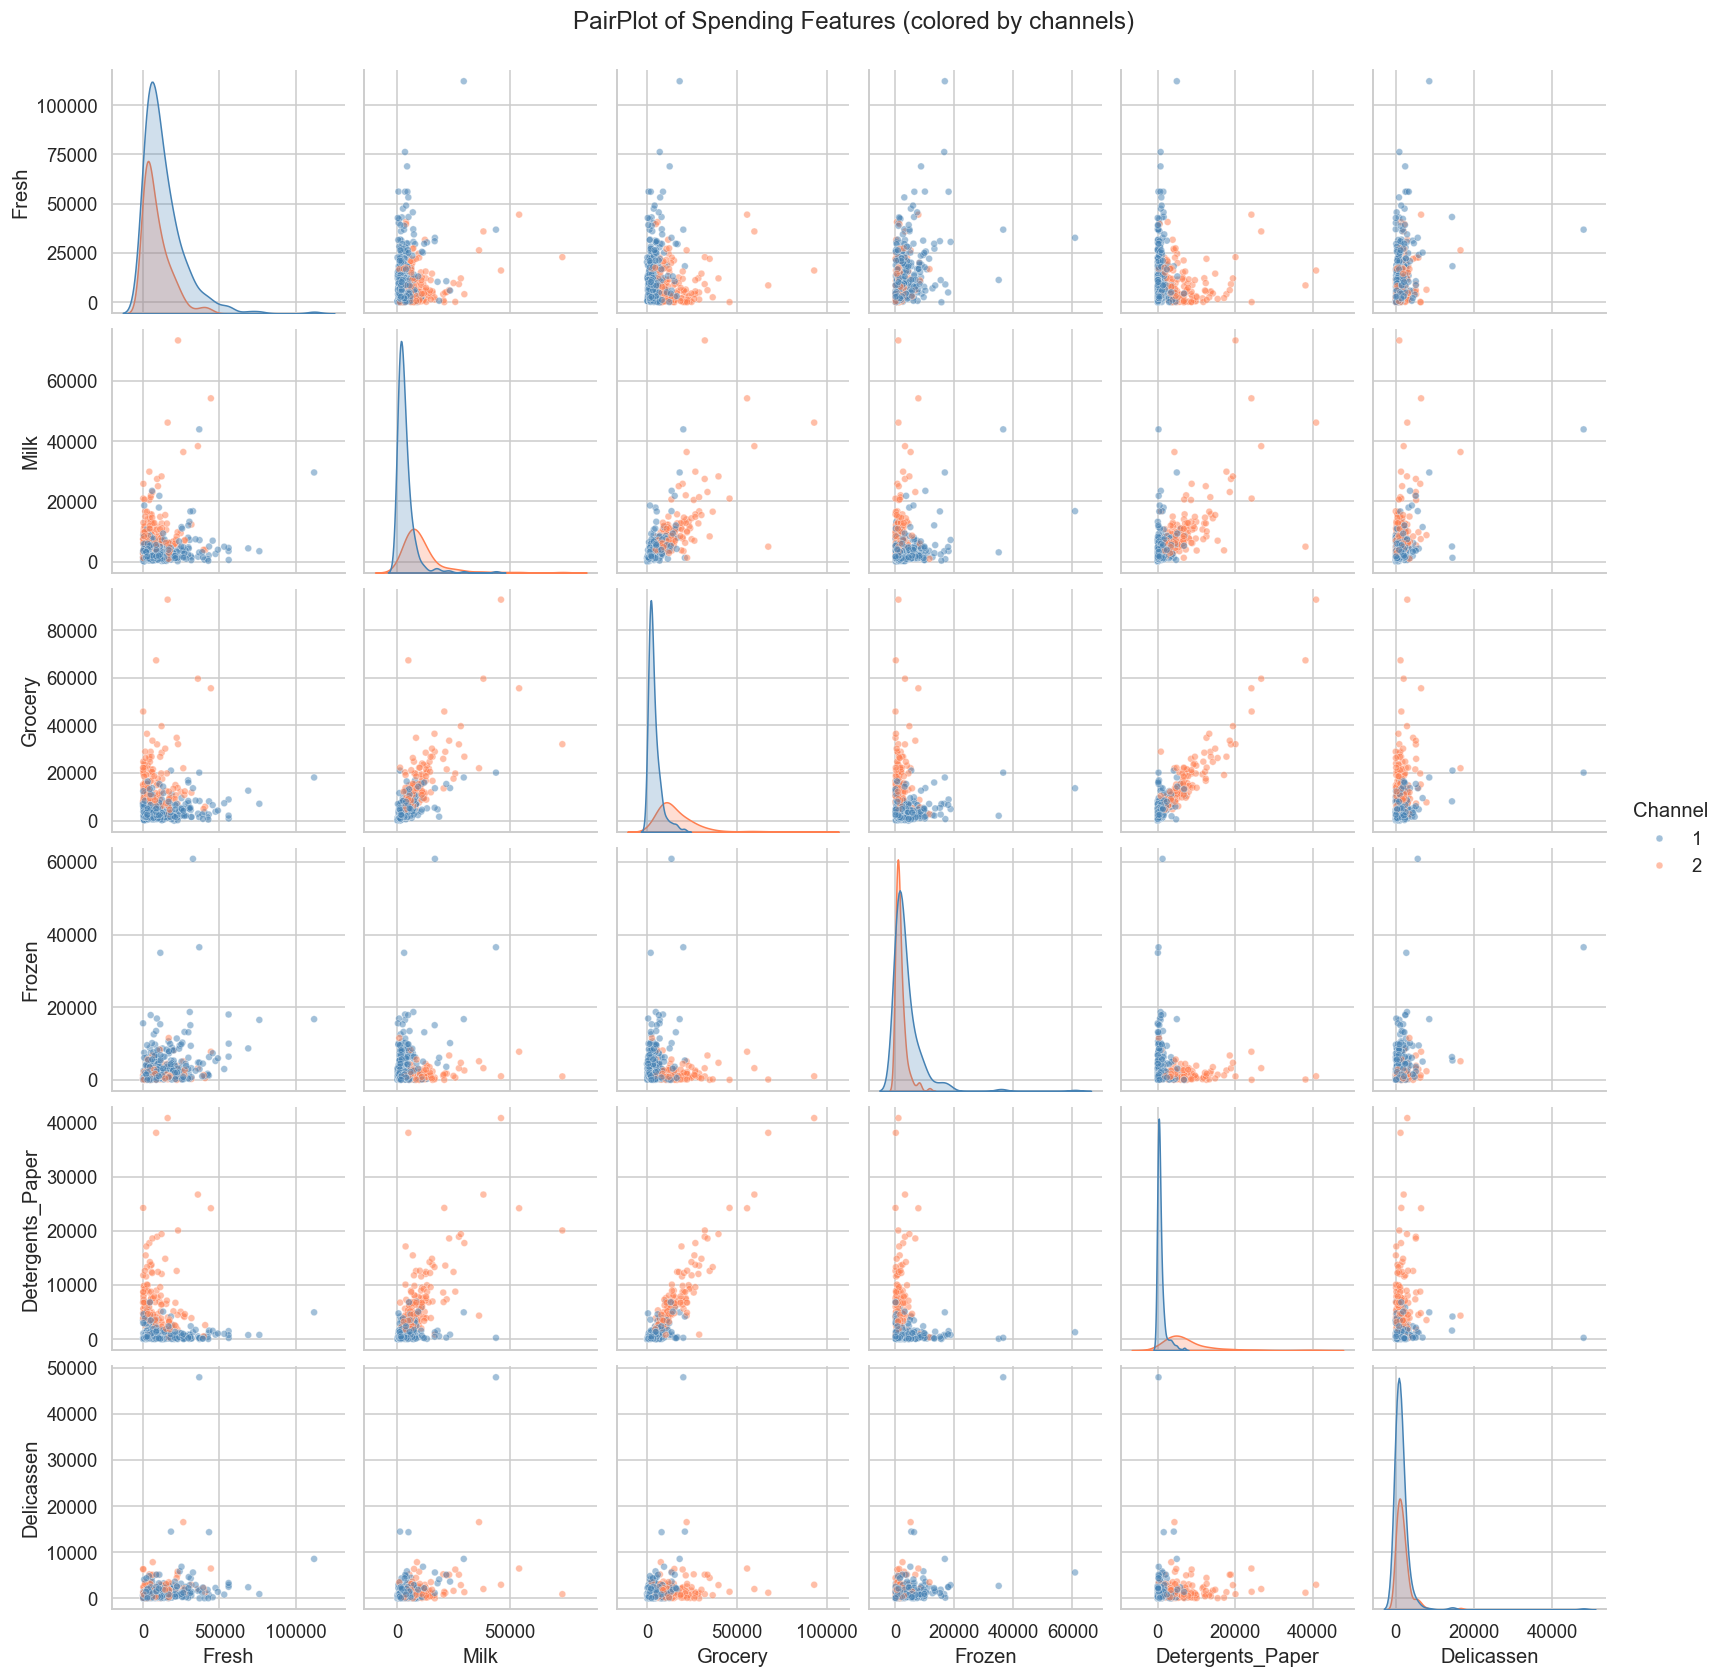

In [16]:
sns.pairplot(wholesale_customers_data[spending_cols + ['Channel']], hue='Channel', diag_kind='kde', plot_kws={'alpha': 0.5, 's':20}, palette={1:'steelblue', 2:'coral'})
plt.suptitle('PairPlot of Spending Features (colored by channels)', y=1.02)
plt.show()

### 2.5 Channel and Regions Distribution

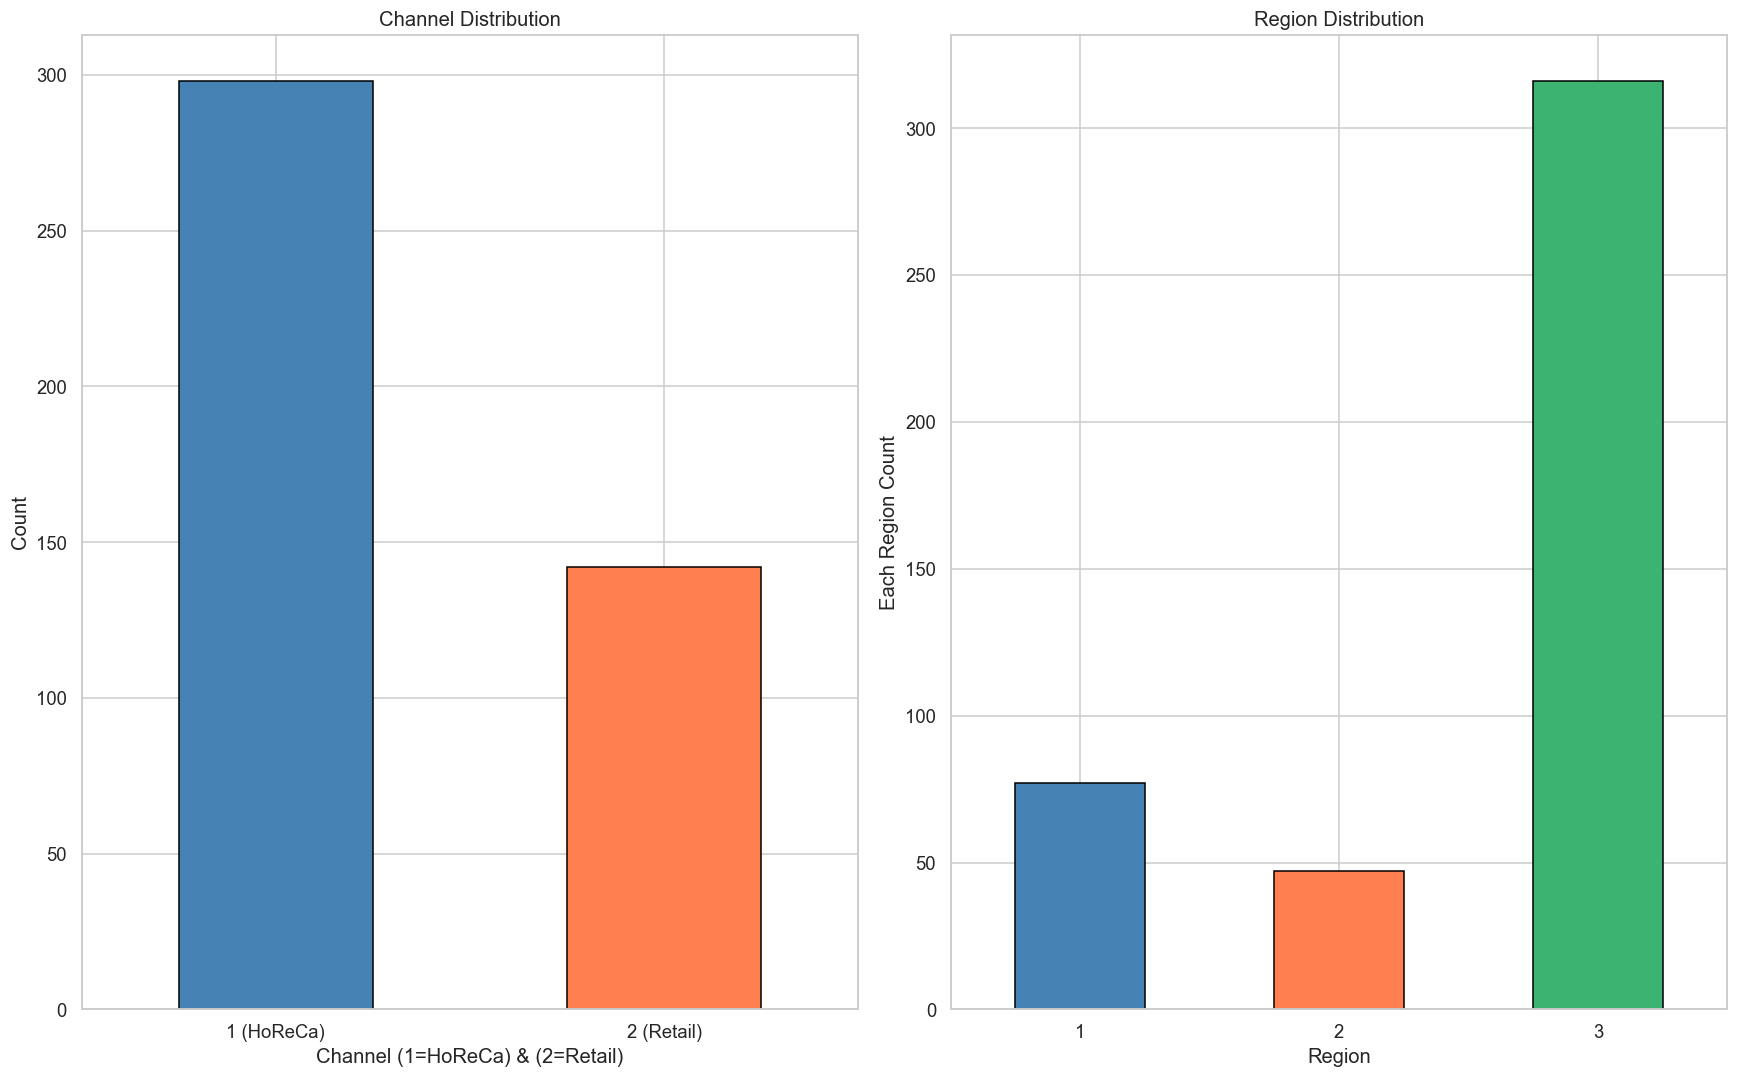

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
wholesale_customers_data['Channel'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue','coral'], edgecolor='black')
axes[0].set_title("Channel Distribution")
axes[0].set_xlabel("Channel (1=HoReCa) & (2=Retail)")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(['1 (HoReCa)', '2 (Retail)'], rotation = 0)

wholesale_customers_data['Region'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral','mediumseagreen'], edgecolor='black')
axes[1].set_title("Region Distribution")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Each Region Count")
axes[1].set_xticklabels(["1", "2", "3"], rotation = 0)

plt.tight_layout()
plt.show()

---
### 3 - Preprocessing

#### 3.1 Log Transform Skew features

- Skewed: not straight/ Distorted Data.
- Skewness: A group of numbers has a 'skew' if it has a unusually high or low cluster of values pullings the average to one side.


In [18]:
wholesale_customers_data_copy = wholesale_customers_data.copy()
for col in spending_cols:
    wholesale_customers_data_copy[col] = np.log1p(wholesale_customers_data[col])
print("Skewness after log-transform:")
print(wholesale_customers_data_copy[spending_cols].skew().round(2))

Skewness after log-transform:
Fresh              -1.58
Milk               -0.22
Grocery            -0.67
Frozen             -0.35
Detergents_Paper   -0.24
Delicassen         -1.09
dtype: float64


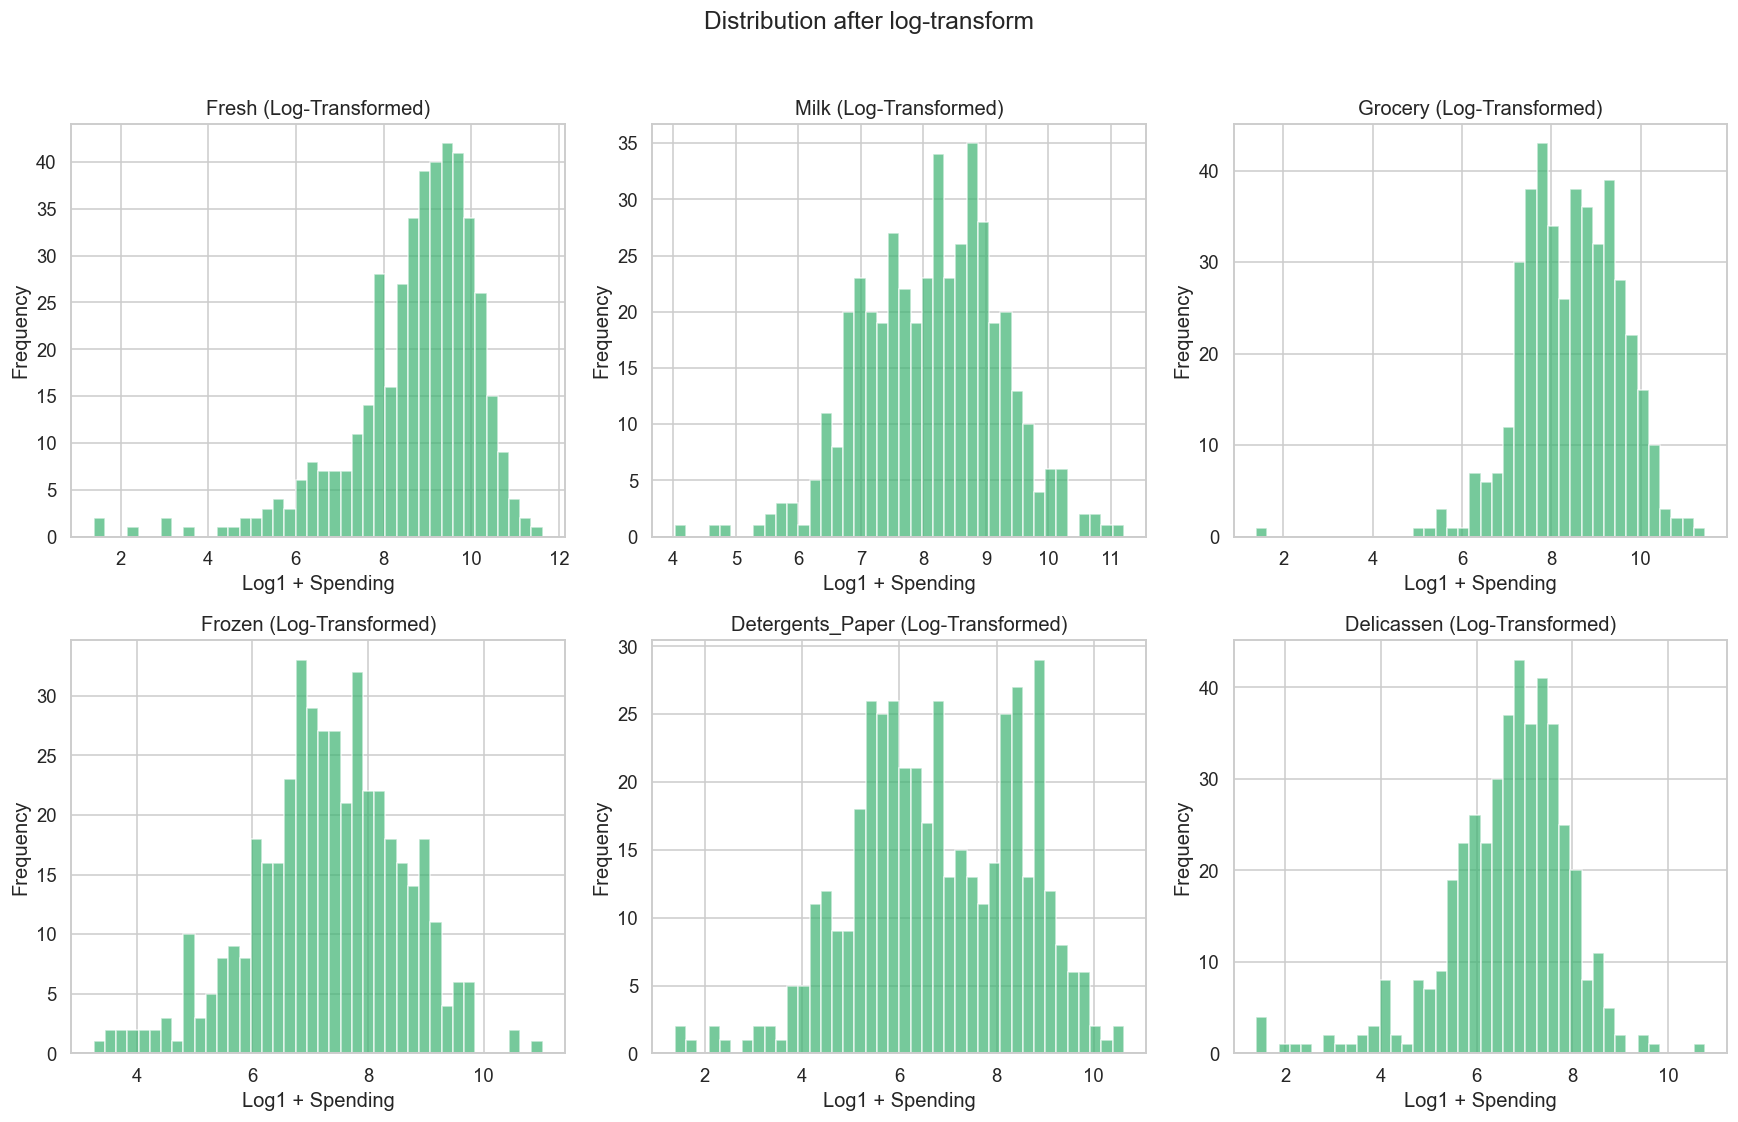

In [19]:
fig, axes = plt.subplots(2, 3, figsize = (16, 10))
for i, col in enumerate(spending_cols):
    ax = axes[i //3, i % 3]
    ax.hist(wholesale_customers_data_copy[col], bins=40, color="mediumseagreen", alpha = 0.7)
    ax.set_title(f"{col} (Log-Transformed)")
    ax.set_xlabel("Log1 + Spending")
    ax.set_ylabel("Frequency")
plt.suptitle('Distribution after log-transform', fontsize = 16, y = 1.02)
plt.tight_layout()
plt.show() 

#### 3.2 Feature Scaling

We standardize(zero mean, unit variance) using standardscaling. This is crucial for distance based clustering algorithms(k-means, DBSCAN). We use spending features only as the primary matrix (dropping channel/region to avoid trivially recovering those labels).


In [20]:
scaler = StandardScaler()
X = scaler.fit_transform(wholesale_customers_data_copy[spending_cols])
print(f"Feature matrix shape : {X.shape}")

Feature matrix shape : (440, 6)


---
### 4 - Clustering & Evaluation
#### 4.1 K-Means Clustering
- Silhoutte Score: It is a clustering validation measure that quantifies how well data point lies withing its cluster relaive to other clusters. it ranges between -1 to +1 and can be applied with any dissimilarity(Euclidean distance) measures. Higher the value of silhoutte score, better the clustering.
##### Simply Put: 
- +1 : The clusters are far to each other.
- 0 - 1 : The clusters are good seperated.
- 0 : Overlapping / unclear
- 0 - -1 :   Bad
- -1 : Very poor clustering


In [21]:
k_range = range(2, 11)
inertias = []
silhoutte_score_list = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhoutte_score_list.append(sil)
    print(f"K: {k}, Inertia: {km.inertia_:.1f}, Silhoutte Score: {sil: .4f}")

K: 2, Inertia: 1844.1, Silhoutte Score:  0.2903
K: 3, Inertia: 1553.4, Silhoutte Score:  0.2594
K: 4, Inertia: 1386.9, Silhoutte Score:  0.1885
K: 5, Inertia: 1266.1, Silhoutte Score:  0.1916
K: 6, Inertia: 1174.8, Silhoutte Score:  0.2009
K: 7, Inertia: 1086.4, Silhoutte Score:  0.1958
K: 8, Inertia: 1028.5, Silhoutte Score:  0.1852
K: 9, Inertia: 973.1, Silhoutte Score:  0.1965
K: 10, Inertia: 932.0, Silhoutte Score:  0.1905


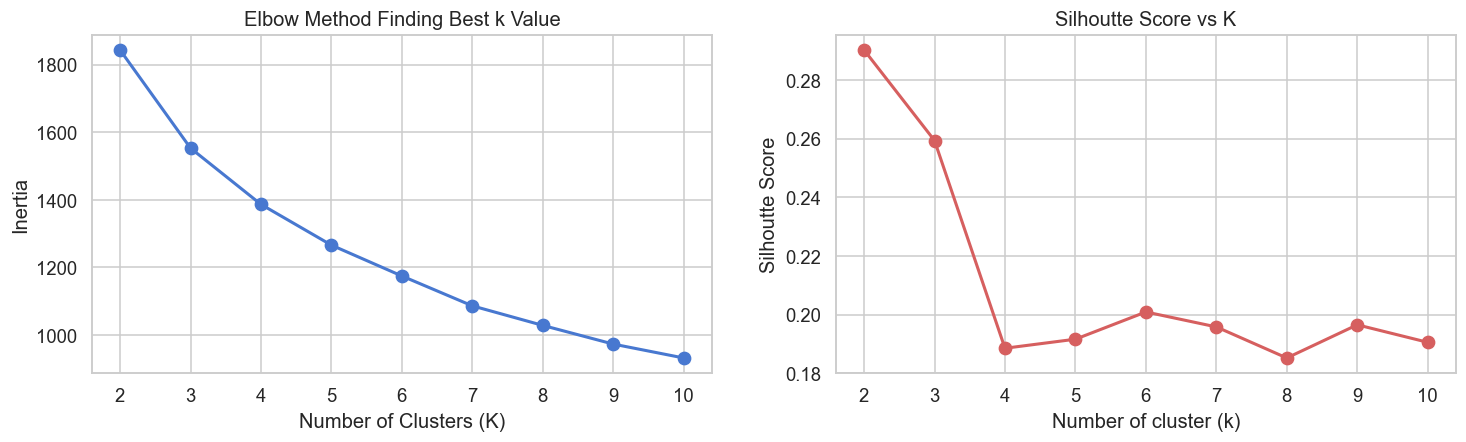

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (16, 4))
axes[0].plot(k_range, inertias, 'bo-', linewidth = 2, markersize = 8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method Finding Best k Value')
axes[0].set_xticks(list(k_range))
axes[0].grid(True)

axes[1].plot(k_range, silhoutte_score_list, 'ro-', linewidth = 2, markersize = 8)
axes[1].set_xlabel("Number of cluster (k)")
axes[1].set_ylabel("Silhoutte Score")
axes[1].set_title("Silhoutte Score vs K")
axes[1].set_xticks(list(k_range))
axes[1].grid(True)

**Observation**: The elbow plot shows a bend around k = 2 - 3, and the silhoutte score is typically high at both k = 2, 3. We proceed with the both k = 2 and k = 3.

In [23]:
km_2 = KMeans(n_clusters=2, n_init=10, random_state=SEED)
km_3 = KMeans(n_clusters=3, n_init=10, random_state=SEED)

labels_km2 = km_2.fit_predict(X)
labels_km3 = km_3.fit_predict(X)

print(f"K Means (k = 2) Silhoutte Score : {silhouette_score(X, labels_km2):.4f}")
print(f"K Means (k = 3) Silhoutte Score : {silhouette_score(X, labels_km3):.4f}")
print(f"\n Cluster Sizes (K = 2) : {np.bincount(labels_km2)}")
print(f"\n Cluster Sizes (K = 3) : {np.bincount(labels_km3)}")


K Means (k = 2) Silhoutte Score : 0.2903
K Means (k = 3) Silhoutte Score : 0.2594

 Cluster Sizes (K = 2) : [252 188]

 Cluster Sizes (K = 3) : [ 80 147 213]


#### 4.2 Hierarchial Clustering

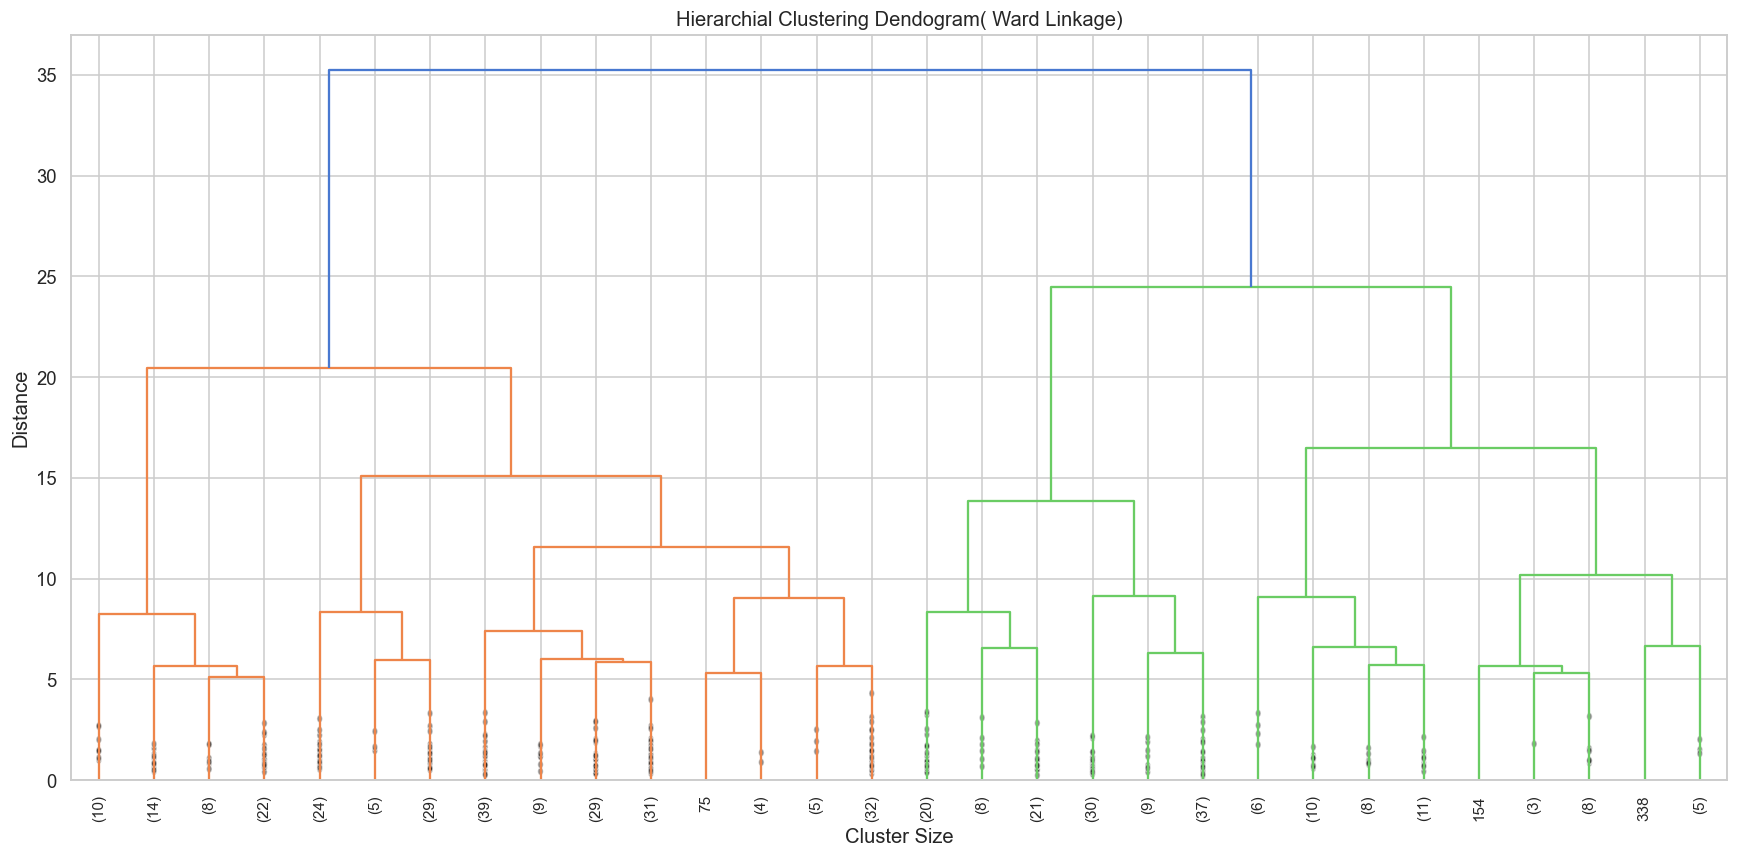

In [24]:
plt.figure(figsize=(16, 8))
Z = linkage(X, method='ward')
dendrogram(Z, truncate_mode='lastp', p = 30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title("Hierarchial Clustering Dendogram( Ward Linkage)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [25]:
agg2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg3 = AgglomerativeClustering(n_clusters=3, linkage='ward')

label_agg2  = agg2.fit_predict(X)
label_agg3  = agg3.fit_predict(X)

print(f"Agglomerate (k = 2) - Silhouette : {silhouette_score(X, label_agg2):.4f}")
print(f"Agglomerate (k = 3) - Silhouette : {silhouette_score(X, label_agg3):.4f}")
print(f"\nCluster Sizes (k=2) : {np.bincount(label_agg2)}")
print(f"\nCluster Sizes (k=3) : {np.bincount(label_agg3)}")

Agglomerate (k = 2) - Silhouette : 0.2585
Agglomerate (k = 3) - Silhouette : 0.2547

Cluster Sizes (k=2) : [178 262]

Cluster Sizes (k=3) : [262  53 125]


### 4.3 DBSCAN

In [26]:
eps_values = [0.50, 0.75, 1.00, 1.25, 1.50, 2.00]
min_sample_val = [3, 5, 7, 10]

dbscan_results = []
for eps in eps_values:
    for ms in min_sample_val:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels_db = dbscan.fit_predict(X)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = (labels_db == -1).sum()
        sil = silhouette_score(X, labels_db) if n_clusters >= 2 else -1
        dbscan_results.append({'eps': eps, 'min_samples' : ms, 'n_clusters' : n_clusters, 'n_noise' : n_noise, 'silhouette_score' : round(sil, 4)})

dbscan_df = pd.DataFrame(dbscan_results)
print(dbscan_df.to_string(index=False))

 eps  min_samples  n_clusters  n_noise  silhouette_score
0.50            3           8      396           -0.3993
0.50            5           1      435           -1.0000
0.50            7           0      440           -1.0000
0.50           10           0      440           -1.0000
0.75            3           9      218           -0.3170
0.75            5           4      281           -0.2599
0.75            7           3      323           -0.1475
0.75           10           3      385           -0.2741
1.00            3           6       91           -0.1616
1.00            5           1      124           -1.0000
1.00            7           2      134            0.0608
1.00           10           1      170           -1.0000
1.25            3           2       53            0.0712
1.25            5           1       70           -1.0000
1.25            7           1       74           -1.0000
1.25           10           1       84           -1.0000
1.50            3           2  

- eps = How far should I look around a point?
- min_samples = How many points do I need nearby to call this area dense?
- n_clusters = How many groups did DBSCAN discover?
- n_noise = How many points couldn't belong to a dense group?
- silhouette = How well separated are the discovered groups?

In [27]:
dbscan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   eps               24 non-null     float64
 1   min_samples       24 non-null     int64  
 2   n_clusters        24 non-null     int64  
 3   n_noise           24 non-null     int64  
 4   silhouette_score  24 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 1.1 KB


In [28]:
best_row = dbscan_df[dbscan_df['n_clusters'] >= 2].sort_values('silhouette_score', ascending=False).iloc[0]
print(f"Best DBSCAN = eps : {best_row['eps']}, min_samples : {best_row['min_samples']}, n_clusters : {best_row['n_clusters']}, n_noise : {best_row['n_noise']}, silhoutte : {best_row['silhouette_score']}")

db_best = DBSCAN(eps=best_row['eps'], min_samples=int(best_row['min_samples']))
labels_dbscan = db_best.fit_predict(X)

Best DBSCAN = eps : 1.5, min_samples : 3.0, n_clusters : 2.0, n_noise : 35.0, silhoutte : 0.2989


#### 4.4 Comparison of the Methods - KMeans, DBSCAN, Agglomerate

In [37]:
comparison = pd.DataFrame({
    'Method' : ['KMeans(k=2)', 'KMeans(k=3)', 'Agglomerate(K=2)', 'Agglomerate(K=3)',
                f"DBSCAN (eps={best_row['eps']} & min_samples={int(best_row['min_samples'])})"],
    'Silhoute Score' : [
        silhouette_score(X, labels_km2),
        silhouette_score(X, labels_km3),
        silhouette_score(X, label_agg2),
        silhouette_score(X, label_agg3),
        best_row['silhouette_score']
    ]
})
comparison = comparison.sort_values('Silhoute Score', ascending=False)
print(comparison.to_string(index=False))

                          Method  Silhoute Score
DBSCAN (eps=1.5 & min_samples=3)        0.298900
                     KMeans(k=2)        0.290328
                     KMeans(k=3)        0.259416
                Agglomerate(K=2)        0.258495
                Agglomerate(K=3)        0.254657


---

## 5 -- Cluster Profiling & Communication

#### 5.1 Assign Cluster Labels

In [38]:
# Use KMeans k = 2 as primary result (Highest Silhoute Score expected)
wholesale_customers_data['Cluster'] = labels_km2

print("Cluster Distribution: ")
print(wholesale_customers_data['Cluster'].value_counts().sort_index())

Cluster Distribution: 
Cluster
0    252
1    188
Name: count, dtype: int64


#### 5.2 Cluster Profiles (Original Scales)

In [39]:
print("==== Mean Spending per Cluster====")
cluster_means = wholesale_customers_data.groupby('Cluster')[spending_cols].mean().round(1)
print(cluster_means)
print()

print("==== Median Spending per Cluster====")
cluster_median = wholesale_customers_data.groupby('Cluster')[spending_cols].median().round(1)
print(cluster_median)
print()

==== Mean Spending per Cluster====
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                 
0        13973.1   2401.8   2918.7  3705.7             491.9      1038.0
1         9355.9  10346.4  14697.1  2222.5            6084.5      2177.4

==== Median Spending per Cluster====
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                
0        10347.5  1871.0   2406.0  2225.0             327.5       749.5
1         5406.5  7690.5  11527.0  1061.5            4495.0      1388.5



In [40]:
print("=== Channel Distribution per cluster ===")
print(pd.crosstab(wholesale_customers_data['Cluster'], wholesale_customers_data['Channel'], normalize='index').round(3))
print()

print("Region Distribution per cluster")
print(pd.crosstab(wholesale_customers_data['Cluster'], wholesale_customers_data['Region'], normalize='index').round(3))


=== Channel Distribution per cluster ===
Channel      1      2
Cluster              
0        0.968  0.032
1        0.287  0.713

Region Distribution per cluster
Region       1      2      3
Cluster                     
0        0.190  0.111  0.698
1        0.154  0.101  0.745


### 5.3 Cluster Centroid HeatMap

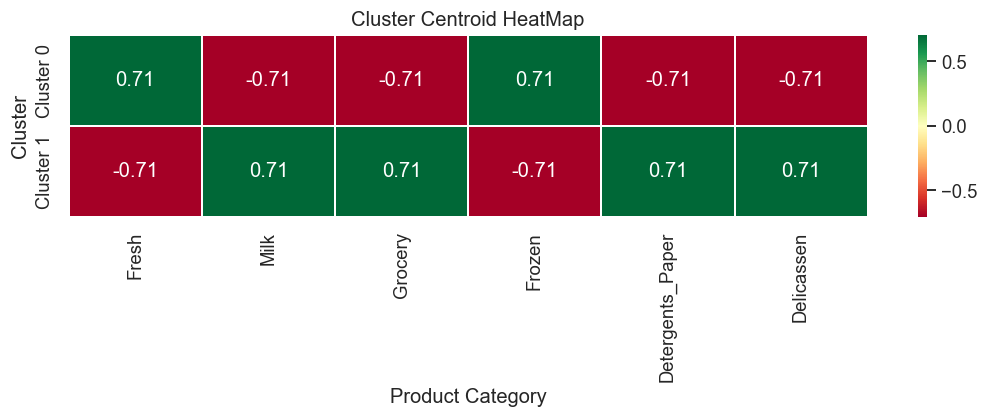

In [41]:
cluster_means_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

plt.figure(figsize=(10, 4))
sns.heatmap(cluster_means_z, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=1, yticklabels=[f"Cluster {i}" for i in cluster_means_z.index])
plt.title("Cluster Centroid HeatMap")
plt.xlabel("Product Category")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

#### 5.3 PCA Visualization
- PCA : Principal Component Analysis
- it is a statistics technique that simplifies complex, high dimensional datasets into fewer dimensions(principal components) still retaining the information and variance.

Explained Variance Ratio : [0.4408 0.2719]
Total variance explained: 0.7127


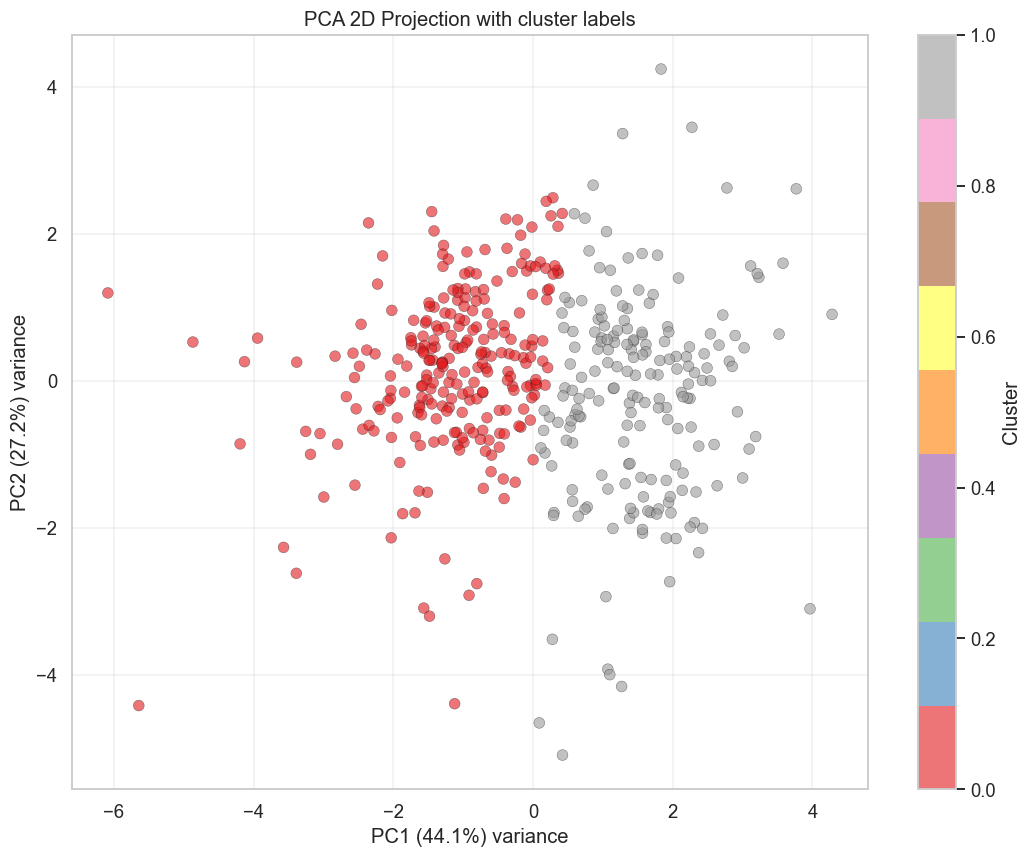

In [46]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)

print(f"Explained Variance Ratio : {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c= wholesale_customers_data['Cluster'], cmap='Set1', alpha=0.6, s = 50, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label = 'Cluster')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) variance")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) variance")
plt.title("PCA 2D Projection with cluster labels")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 5.5 T-SNE Visualization

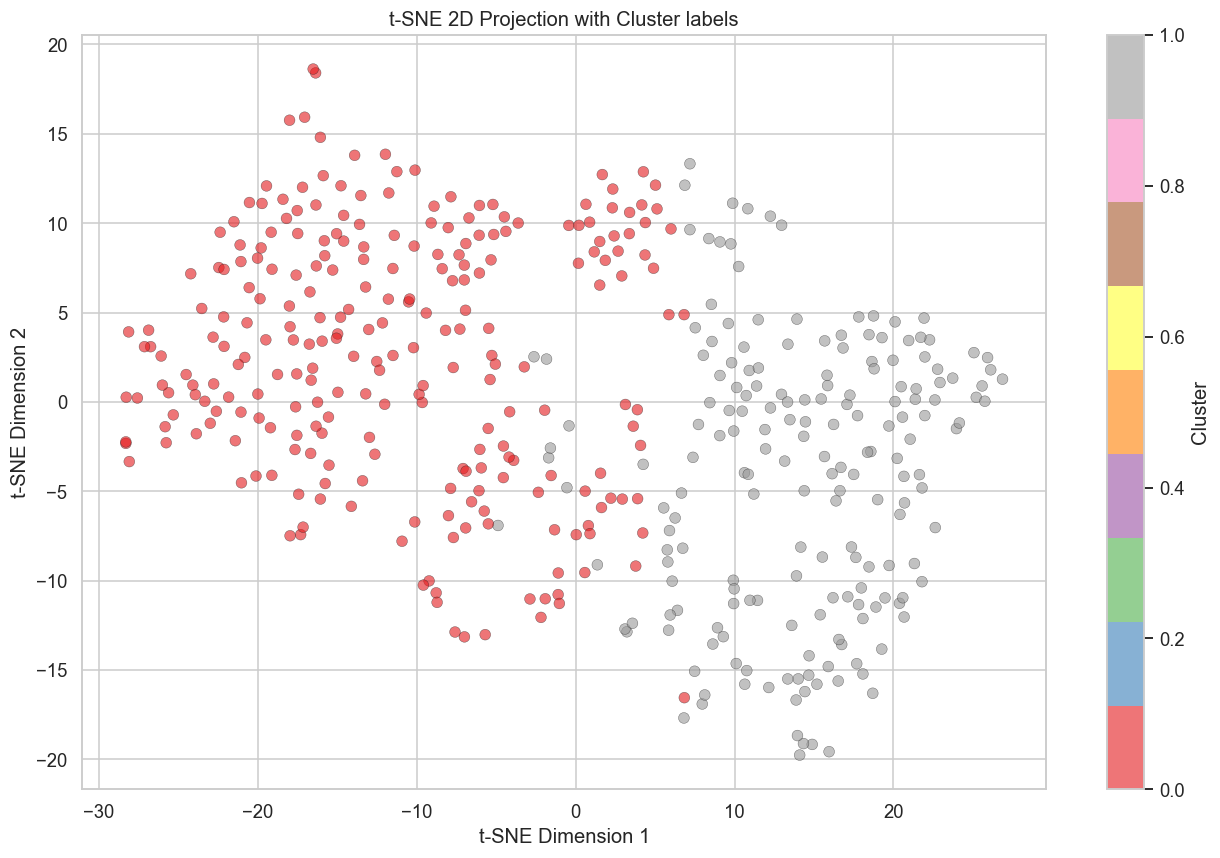

In [47]:
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c = wholesale_customers_data['Cluster'], cmap = 'Set1', alpha=0.6, s = 50, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label = 'Cluster')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE 2D Projection with Cluster labels')
plt.tight_layout()
plt.show()

#### 5.6 ALL Methods Side-by-Side (PCA Space)


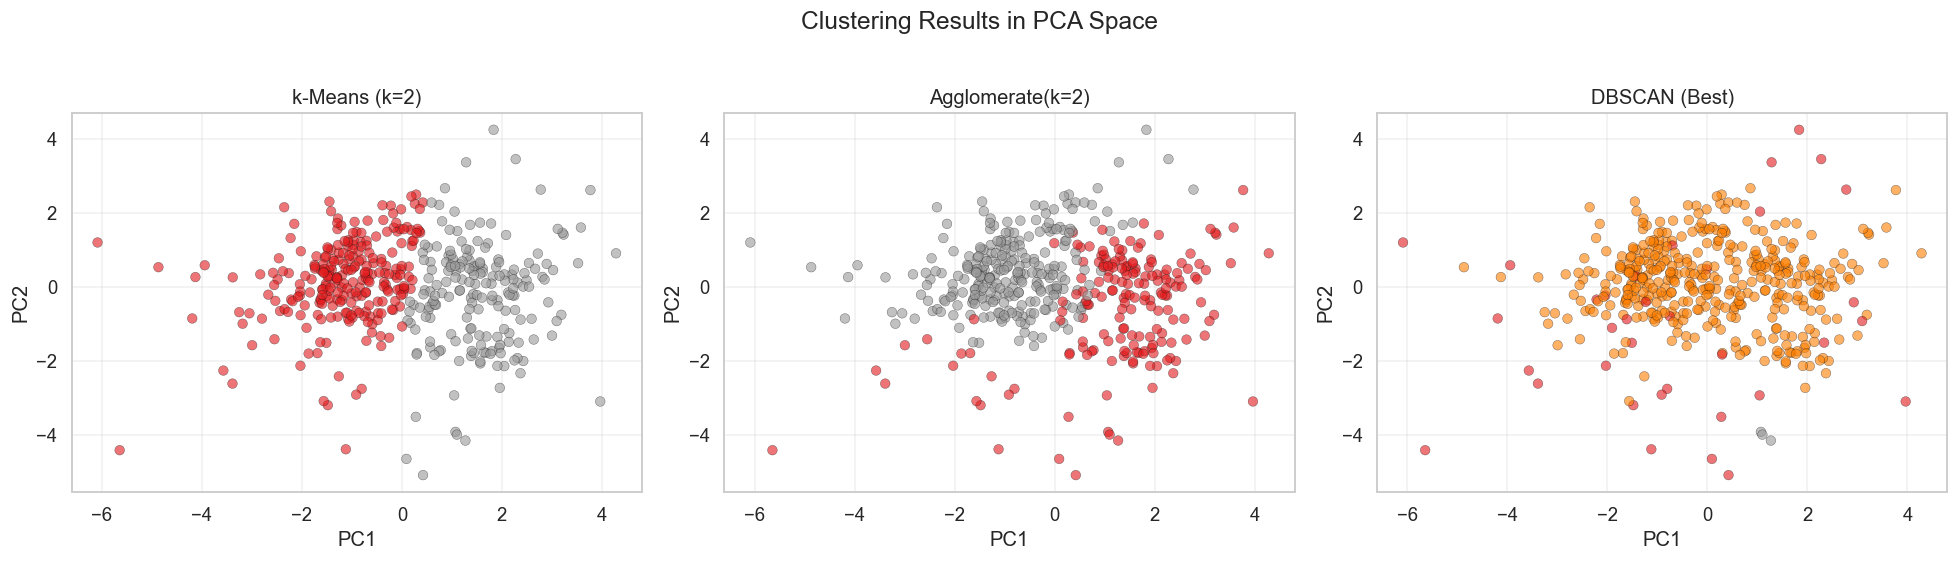

In [50]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

for ax, labels, title in zip(axes, [labels_km2, label_agg2, labels_dbscan], ['k-Means (k=2)', 'Agglomerate(k=2)', 'DBSCAN (Best)']):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', alpha=0.6, s=40, edgecolors='k', linewidths=0.3)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

plt.suptitle("Clustering Results in PCA Space", fontsize = 16, y = 1.02)
plt.tight_layout()
plt.show()

#### 5.7 Business Interpretations
##### Cluster 0 - Fresh Focused (HoReCa) Customers:
- Higher Spending on fresh, Frozen, and Delicassen
- Lower Spending on Groceries, Milk, Detergents
- Likely corresponds to hotels/resturants/Cafe(Channel 1) customer buying pherishables and specialty items in bulk
- Business Action : Offer Bulk discounts on fresh produce and frozen goods;ensure reliable cold-chain delivery
##### Cluster 1 - Grocery Focused (Retail) Customers
- Higher Spending on Grocery, Milk, Detergents
- Lower Spending on Fresh and frozen
- Likely corresponds to retails (channel 2) customers stocking households staples.
- Business Action : Place grocery and detergents products near by in stores. Provide discounts on groceries and detergents + loyality programs for repeated customers.

### 6 - Final Conclusion

- **Best Algorithm** : K-Means Clustering (k = 2) is clean, interpretable segmentations between the channels (HoReCa) & (Retail)
- **Preprocessing Matters** :  Log Transforming the heavily skewed feature and standardizing imrpoced the cluster quality.
-  **Two Natural Segments** : Natural Segmentation of Two Nature of Customer (Hotels, Restuarants, Cafe) - Highly purchased products are fresh and frozen (Retail Customer) - Purchased more house hold products milk, groceries and detergents.
- **Business Decision** : This segments can help us with the targetted marketting, inventory management, and differentiated discounts/pricing for the different types of customers.